In [1]:
from torchvision import transforms
from torchvision.datasets import ImageFolder

img_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Image loader
dataset = ImageFolder(
    root=r"D:\Datasets\Oxford-IIIT-Pets",
    transform=img_transforms
)

In [2]:
import math
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt

def plot_samples(dataset, num_samples=20, cols=5):
    """
    Plot some samples from the dataset
    """
    
    plt.figure(figsize=(15, 15))

    step = len(dataset) // (num_samples - 1)

    for i in range(0, len(dataset), step):
        img, label = dataset[i]

        plt.subplot(
            math.ceil(num_samples / cols),
            cols,
            i // step + 1
        )
        plt.imshow(to_pil_image(img))
        plt.title(dataset.classes[label])
        plt.axis("off")

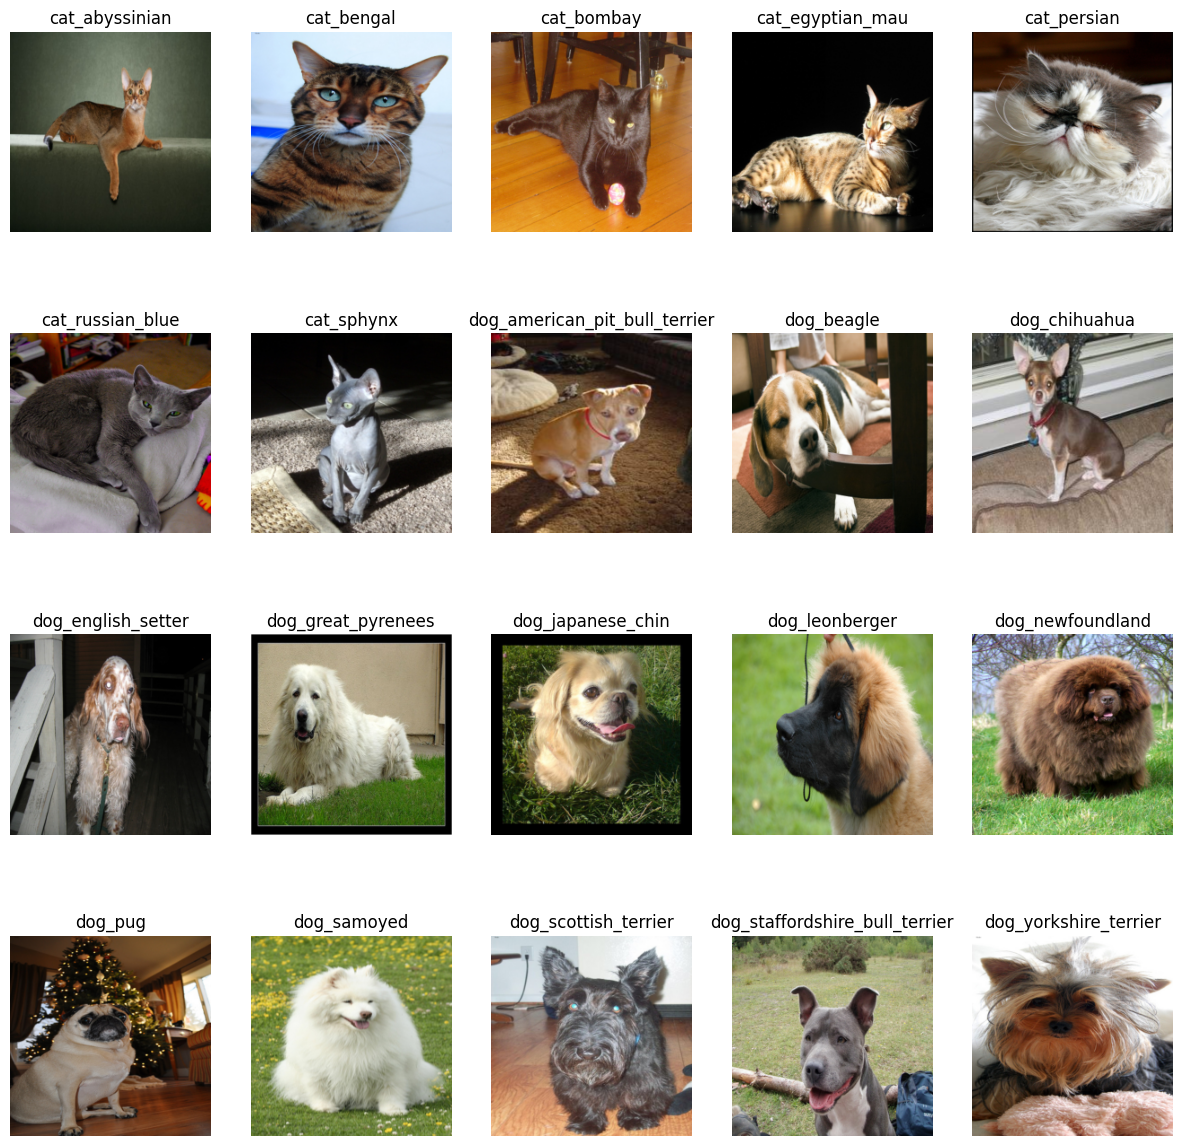

In [3]:
plot_samples(dataset)

In [4]:
import torch
import torch.nn as nn
from einops.layers.torch import Rearrange

class PatchEmbedding(nn.Sequential):
    def __init__(
        self,
        num_channels: int,
        patch_size: int,
        embed_dim: int
    ):
        super().__init__(
            Rearrange("b c (h p1) (w p2) -> b (h w) (p1 p2 c)", p1=patch_size, p2=patch_size),
            nn.Linear(patch_size * patch_size * num_channels, embed_dim)
        )

In [5]:
class MultiheadAttention(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        dropout: float = 0.0
    ):
        super().__init__()

        assert embed_dim % num_heads == 0, \
            "embed_dim must be divisible by num_heads"

        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # One projection for Q, K, V together
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)

        # Final output projection
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, P, E = x.shape

        # Project to Q, K, V together
        # (B, P, E) -> (B, P, 3*E)
        qkv = self.qkv(x)

        # Split into Q, K, V
        # (B, P, 3*E) -> (B, P, E) * 3
        q, k, v = qkv.chunk(3, dim=-1)

        # Split embedding dimension into heads
        # (B, P, E) -> (B, P, h, H)
        q = q.view(B, P, self.num_heads, self.head_dim)
        k = k.view(B, P, self.num_heads, self.head_dim)
        v = v.view(B, P, self.num_heads, self.head_dim)

        # Move heads before patches
        # (B, P, h, H) -> (B, h, P, H)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # Attention scores
        # (B, h, P, H) @ (B, h, H, P) -> (B, h, P, P)
        attn_scores = q @ k.transpose(-2, -1)
        attn_scores = attn_scores / (self.head_dim ** 0.5)

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Weighted sum of values
        # (B, h, P, P) @ (B, h, P, H) -> (B, h, P, H)
        attn_output = attn_weights @ v

        # Move heads after patches
        # (B, h, P, H) -> (B, P, h, H)
        attn_output = attn_output.transpose(1, 2)

        # Merge heads
        # (B, P, h, H) -> (B, P, E)
        attn_output = attn_output.contiguous().view(B, P, E)

        # Linear projection
        attn_output = self.out_proj(attn_output)

        return attn_output

In [6]:
class MLP(nn.Sequential):
    def __init__(
        self,
        embed_dim: int,
        hidden_dim: int,
        dropout: float = 0.0
    ):
        super().__init__(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )

In [7]:
class EncoderBlock(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        hidden_dim: int,
        dropout: float = 0.0
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.multihead_attention = MultiheadAttention(
            embed_dim,
            num_heads,
            dropout
        )

        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(
            embed_dim,
            hidden_dim,
            dropout
        )

    def forward(self, x):
        out = self.norm1(x)
        out = self.multihead_attention(out)

        # Residual connection
        x = x + out

        out = self.norm2(x)
        out = self.mlp(out)

        # Residual connection
        x = x + out

        return x

In [8]:
from einops import repeat

class VisionTransformer(nn.Module):
    def __init__(
        self,
        num_channels: int = 3,
        image_size: int = 224,
        patch_size: int = 16,
        embed_dim: int = 384,
        num_heads: int = 6,
        num_layers: int = 8,
        out_dim: int = 37,
        dropout: float = 0.1
    ):
        super().__init__()

        # Patch embedding
        self.patch_embedding = PatchEmbedding(
            num_channels,
            patch_size,
            embed_dim
        )

        # CLS token (learnable)
        # Shape: (1, 1, embed_dim)
        self.cls_token = nn.Parameter(
            torch.rand(1, 1, embed_dim)
        )

        # Positional embedding (learnable)
        # Shape: (1, 1 + num_patches, embed_dim)
        # (1 + num_patches) because we concatenate CLS token with patch embeddings of each image in a batch
        num_patches = (image_size // patch_size) ** 2
        self.positional_embedding = nn.Parameter(
            torch.randn(1, 1 + num_patches, embed_dim)
        )

        # Transformer encoder
        self.layers = nn.ModuleList([
            EncoderBlock(
                embed_dim,
                num_heads,
                embed_dim,
                dropout
            ) for _ in range(num_layers)
        ])

        # Classification head
        self.classification_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, out_dim)
        )

    def forward(self, image):
        # Get patch embedding vectors
        # (B, p, E)
        x = self.patch_embedding(image)

        # Repeat CLS token to match batch dimension and add CLS token to all inputs (before first patch embedding vector; index 0)
        # (1, 1, E) -> (B, 1, E)
        cls_tokens = repeat(self.cls_token, "1 1 e -> b 1 e", b=x.shape[0])
        # (B, 1+p, E) -> (B, P, E)
        x = torch.cat((cls_tokens, x), dim=1)

        # Add positional embedding
        # (B, P, E) + (1, P, E) -> (B, P, E)
        x = x + self.positional_embedding

        # Transformer encoder layers
        for layer in self.layers:
            x = layer(x)

        # Output based on CLS token
        # (B, E) -> (B, C)
        return self.classification_head(x[:, 0, :])

In [9]:
model = VisionTransformer()

print(model)

VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (0): Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=16, p2=16)
    (1): Linear(in_features=768, out_features=384, bias=True)
  )
  (layers): ModuleList(
    (0-7): 8 x EncoderBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (multihead_attention): MultiheadAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (out_proj): Linear(in_features=384, out_features=384, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (0): Linear(in_features=384, out_features=384, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=384, out_features=384, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classification_head): Sequential(
    (0): LayerNorm((384,), eps=1e-0

In [10]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

# Image ids and labels
ids = list(range(len(dataset)))
labels = [label for _, label in dataset.samples]

# Split dataset into train and evaluation (validation and test) sets
train_ids, eval_ids, _, eval_labels = train_test_split(
    ids, labels,
    test_size=0.25,
    shuffle=True,
    stratify=labels
)
# Split evaluation set into validation and test sets
val_ids, test_ids = train_test_split(
    eval_ids,
    test_size=0.5,
    shuffle=True,
    stratify=eval_labels
)

# Train, validation and test datasets
train_dataset = Subset(dataset, train_ids)
val_dataset = Subset(dataset, val_ids)
test_dataset = Subset(dataset, test_ids)

# Train, validation and test dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

model = model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)
criterion = nn.CrossEntropyLoss()

Using: cuda


In [12]:
from tqdm import tqdm

NUM_EPOCHS = 25

# Store train and validation loss and accuracy at each epoch
train_loss_history = []
train_accuracy_history = []
val_loss_history = []
val_accuracy_history = []

for epoch in range(NUM_EPOCHS):
    print(f"=== Epoch {epoch + 1}/{NUM_EPOCHS} ===")

    model.train()

    total_loss = 0.0
    correct_preds = 0

    for inputs, labels in tqdm(train_dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct_preds += (outputs.argmax(dim=-1) == labels).sum().item()

    train_loss = total_loss / len(train_dataloader)
    train_accuracy = correct_preds / len(train_dataset)
    train_loss_history.append(train_loss)
    train_accuracy_history.append(train_accuracy)
    print(f"Train loss: {train_loss:.4f} - Train accuracy: {train_accuracy:.2%}")

    model.eval()

    total_loss = 0.0
    correct_preds = 0

    for inputs, labels in val_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        
        total_loss += criterion(outputs, labels).item()
        correct_preds += (outputs.argmax(dim=-1) == labels).sum().item()

    val_loss = total_loss / len(val_dataloader)
    val_accuracy = correct_preds / len(val_dataset)
    val_loss_history.append(val_loss)
    val_accuracy_history.append(val_accuracy)
    print(f"Validation loss: {val_loss:.4f} - Validation accuracy: {val_accuracy:.2%}")

=== Epoch 1/25 ===


100%|██████████| 174/174 [00:27<00:00,  6.37it/s]


Train loss: 3.6422 - Train accuracy: 3.48%
Validation loss: 3.5256 - Validation accuracy: 4.65%
=== Epoch 2/25 ===


100%|██████████| 174/174 [00:25<00:00,  6.90it/s]


Train loss: 3.4515 - Train accuracy: 6.66%
Validation loss: 3.4283 - Validation accuracy: 6.71%
=== Epoch 3/25 ===


...

Train loss: 0.7737 - Train accuracy: 77.01%
Validation loss: 4.5621 - Validation accuracy: 15.15%
=== Epoch 24/25 ===


100%|██████████| 174/174 [00:26<00:00,  6.68it/s]


Train loss: 0.6384 - Train accuracy: 81.36%
Validation loss: 4.6843 - Validation accuracy: 14.07%
=== Epoch 25/25 ===


100%|██████████| 174/174 [00:25<00:00,  6.73it/s]


Train loss: 0.5559 - Train accuracy: 83.38%
Validation loss: 4.7275 - Validation accuracy: 13.31%


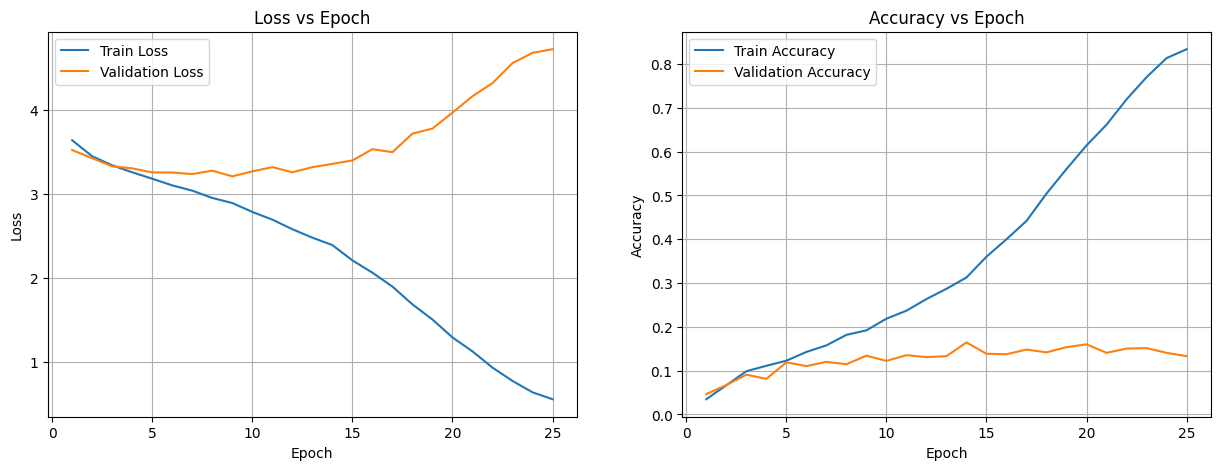

In [13]:
# Plot train and validation loss and accuracy graphs
epochs = [i for i in range(1, NUM_EPOCHS + 1)]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Train/Validation loss vs epoch graph
axes[0].plot(epochs, train_loss_history, label="Train Loss")
axes[0].plot(epochs, val_loss_history, label="Validation Loss")
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid()

# Train/Validation accuracy vs epoch graph
axes[1].plot(epochs, train_accuracy_history, label="Train Accuracy")
axes[1].plot(epochs, val_accuracy_history, label="Validation Accuracy")
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid()

plt.show()

In [14]:
model.eval()

total_loss = 0.0
correct_preds = 0

for inputs, labels in test_dataloader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model(inputs)
    
    total_loss += criterion(outputs, labels).item()
    correct_preds += (outputs.argmax(dim=-1) == labels).sum().item()

test_loss = total_loss / len(test_dataloader)
test_accuracy = correct_preds / len(test_dataset)
print(f"Test loss: {test_loss:.4f} - Test accuracy: {test_accuracy:.2%}")

Test loss: 4.6865 - Test accuracy: 14.94%
